In [2]:
import matplotlib.pyplot as plt
import matplotlib
# Set font size and family for the entire figure
matplotlib.rcParams['font.size'] = 12
matplotlib.rcParams['font.family'] = 'serif'

In [3]:
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Access the file in Google Drive
df = pd.read_csv("/content/drive/MyDrive/data/Drone/DNN-EdgeIIoT-dataset.csv")

/tmp/ipython-input-3943412937.py:2: DtypeWarning: Columns (2,3,6,11,13,14,15,16,17,31,32,34,39,45,51,54,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/data/Drone/DNN-EdgeIIoT-dataset.csv")


In [4]:
df.shape

(2219201, 63)

In [6]:
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2021 23:24:32.816050000,166.75.162.225,192.168.0.128,0,0.0,0.0,0,31814.0,45620.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219197,2021 23:24:32.816595000,70.162.34.183,192.168.0.128,0,0.0,0.0,0,27718.0,45636.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219198,2021 23:24:32.818043000,40.13.95.244,192.168.0.128,0,0.0,0.0,0,18502.0,45672.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP
2219199,2021 23:24:32.820831000,18.132.75.125,192.168.0.128,0,0.0,0.0,0,1862.0,45737.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP


## **Multiclass to Binary Class Conversion**

In [5]:
# ✅ Create a binary column 'Binary_Label'
df['Binary_Label'] = df['Attack_type'].apply(lambda x: 'Normal' if x == 'Normal' else 'Attack')

# ✅ Check the new label distribution
print(df['Binary_Label'].value_counts())

Binary_Label
Normal    1615643
Attack     603558
Name: count, dtype: int64


In [8]:
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Attack_type,Binary_Label
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2021 23:24:32.816050000,166.75.162.225,192.168.0.128,0,0.0,0.0,0,31814.0,45620.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP,Attack
2219197,2021 23:24:32.816595000,70.162.34.183,192.168.0.128,0,0.0,0.0,0,27718.0,45636.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP,Attack
2219198,2021 23:24:32.818043000,40.13.95.244,192.168.0.128,0,0.0,0.0,0,18502.0,45672.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP,Attack
2219199,2021 23:24:32.820831000,18.132.75.125,192.168.0.128,0,0.0,0.0,0,1862.0,45737.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,DDoS_ICMP,Attack


In [6]:
# ✅ Drop the 'Attack_type' column
df.drop(columns=['Attack_type'], inplace=True)

In [7]:
df['Binary_Label'].value_counts()

,count
Binary_Label,
Normal,1615643
Attack,603558


# **Data Preprocessing**

In [11]:
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Binary_Label
0,2021 11:44:10.081753000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
1,2021 11:44:10.162218000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,4.0,MQTT,0,0.0,4.0,0.0,0.0,0.0,0,Normal
2,2021 11:44:10.162271000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
3,2021 11:44:10.162641000,192.168.0.128,192.168.0.101,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0,Normal
4,2021 11:44:10.166132000,192.168.0.101,192.168.0.128,0,0.0,0.0,0,0.0,0.0,0.0,...,0.0,0,Temperature_and_Humidity,24.0,0.0,0.0,0.0,0.0,0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2021 23:24:32.816050000,166.75.162.225,192.168.0.128,0,0.0,0.0,0,31814.0,45620.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Attack
2219197,2021 23:24:32.816595000,70.162.34.183,192.168.0.128,0,0.0,0.0,0,27718.0,45636.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Attack
2219198,2021 23:24:32.818043000,40.13.95.244,192.168.0.128,0,0.0,0.0,0,18502.0,45672.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Attack
2219199,2021 23:24:32.820831000,18.132.75.125,192.168.0.128,0,0.0,0.0,0,1862.0,45737.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,Attack


## **Handle Missing Values**

In [8]:
# Check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]  # Only show columns with missing values

print("Columns with Missing Values:\n", missing_values)


Columns with Missing Values:
 Series([], dtype: int64)


In [9]:

# Identify numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Fill missing values in numerical columns with median
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())

# Fill missing values in categorical columns with mode
df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

# Verify if missing values are filled
print("Missing values after filling:\n", df.isnull().sum().sum())  # Should be 0 if all missing values are handled


Missing values after filling:
 0


In [14]:
df.shape

(2219201, 63)

In [15]:
# Print the names of the features (columns)
print(df.columns)

Index(['frame.time', 'ip.src_host', 'ip.dst_host', 'arp.dst.proto_ipv4',
       'arp.opcode', 'arp.hw.size', 'arp.src.proto_ipv4', 'icmp.checksum',
       'icmp.seq_le', 'icmp.transmit_timestamp', 'icmp.unused',
       'http.file_data', 'http.content_length', 'http.request.uri.query',
       'http.request.method', 'http.referer', 'http.request.full_uri',
       'http.request.version', 'http.response', 'http.tls_port', 'tcp.ack',
       'tcp.ack_raw', 'tcp.checksum', 'tcp.connection.fin',
       'tcp.connection.rst', 'tcp.connection.syn', 'tcp.connection.synack',
       'tcp.dstport', 'tcp.flags', 'tcp.flags.ack', 'tcp.len', 'tcp.options',
       'tcp.payload', 'tcp.seq', 'tcp.srcport', 'udp.port', 'udp.stream',
       'udp.time_delta', 'dns.qry.name', 'dns.qry.name.len', 'dns.qry.qu',
       'dns.qry.type', 'dns.retransmission', 'dns.retransmit_request',
       'dns.retransmit_request_in', 'mqtt.conack.flags',
       'mqtt.conflag.cleansess', 'mqtt.conflags', 'mqtt.hdrflags', 'mqtt.len

In [10]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Preprocessing steps
# Replace infinity and large values with NaNs
#df = df.replace([np.inf, -np.inf], np.nan)
#df = df.replace(to_replace=[r'^(-?\d+\.\d+e\+\d+|-?\d+\.\d+e-\d+|-?\d+\.\d+|-?\d+)$', r'^(-?\d+)$'], value=np.nan, regex=True)

# Drop rows containing NaNs
#df.dropna(inplace=True)

# Separate numerical and categorical columns, excluding the 'Label' column from categorical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
cat_cols = cat_cols.difference(['Binary_Label'])

# Normalize numerical columns
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

# Ensure all categorical values are strings
df[cat_cols] = df[cat_cols].astype(str)

# Encode categorical columns
encoder = LabelEncoder()
df[cat_cols] = df[cat_cols].apply(encoder.fit_transform)

# Display the processed DataFrame
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Binary_Label
0,57650,58101,22987,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,0,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
1,57651,58100,22988,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,5.072089,2,0,-0.197134,5.072089,-0.007583,-0.007155,-0.006838,-0.611205,Normal
2,57652,58101,22987,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,0,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
3,57653,58101,22987,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,0,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
4,57654,58100,22988,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,2,5.072692,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2093397,43780,22988,0,-0.048563,-0.051428,0,3.528228,4.929494,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack
2219197,2093398,121518,22988,0,-0.048563,-0.051428,0,3.047848,4.931297,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack
2219198,2093399,104154,22988,0,-0.048563,-0.051428,0,1.966992,4.935356,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack
2219199,2093400,50370,22988,0,-0.048563,-0.051428,0,0.015448,4.942683,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack


In [11]:
X = df.drop(columns=['Binary_Label'])
y = df['Binary_Label']

In [18]:
df.shape

(2219201, 63)

In [11]:
df['Binary_Label'].value_counts()

,count
Binary_Label,
Normal,1615643
Attack,603558


In [12]:
df

,frame.time,ip.src_host,ip.dst_host,arp.dst.proto_ipv4,arp.opcode,arp.hw.size,arp.src.proto_ipv4,icmp.checksum,icmp.seq_le,icmp.transmit_timestamp,...,mqtt.proto_len,mqtt.protoname,mqtt.topic,mqtt.topic_len,mqtt.ver,mbtcp.len,mbtcp.trans_id,mbtcp.unit_id,Attack_label,Binary_Label
0,57650,58101,22987,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,0,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
1,57651,58100,22988,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,5.072089,2,0,-0.197134,5.072089,-0.007583,-0.007155,-0.006838,-0.611205,Normal
2,57652,58101,22987,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,0,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
3,57653,58101,22987,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,0,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
4,57654,58100,22988,0,-0.048563,-0.051428,0,-0.202928,-0.213412,-0.006116,...,-0.197157,0,2,5.072692,-0.197157,-0.007583,-0.007155,-0.006838,-0.611205,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2219196,2093397,43780,22988,0,-0.048563,-0.051428,0,3.528228,4.929494,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack
2219197,2093398,121518,22988,0,-0.048563,-0.051428,0,3.047848,4.931297,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack
2219198,2093399,104154,22988,0,-0.048563,-0.051428,0,1.966992,4.935356,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack
2219199,2093400,50370,22988,0,-0.048563,-0.051428,0,0.015448,4.942683,-0.006116,...,-0.197157,1,1,-0.197134,-0.197157,-0.007583,-0.007155,-0.006838,1.636113,Attack


In [13]:
!pip install tensorflow

# **Proposed CST-AFNet Model**

In [12]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, LayerNormalization, Conv1D,
    GlobalMaxPooling1D, GlobalAveragePooling1D, Concatenate,
    Bidirectional, GRU, Multiply, Permute, Add, Activation, Reshape,
    Lambda, Flatten, RepeatVector
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# === Load your dataset ===
# Example: df = pd.read_csv("your_dataset.csv")
target_column = "Binary_Label"  # Updated target column

# --- Example dataset (remove when using your real df) ---
# df = pd.DataFrame({
#     "f1": np.random.rand(1000),
#     "f2": np.random.rand(1000),
#     "Binary_Label": np.random.choice(["Normal", "Attack"], size=1000)
# })

# --- Encode string labels to 0/1 ---
le = LabelEncoder()
y = le.fit_transform(df[target_column])  # Converts 'Normal' -> 0, 'Attack' -> 1
y = y.astype(np.float32)

# Features
X = df.drop(columns=[target_column]).values.astype(np.float32)

# --- Attention and building blocks ---
def squeeze_excitation_block(input_tensor, ratio=16):
    channels = input_tensor.shape[-1]
    se = GlobalAveragePooling1D()(input_tensor)
    se = Dense(channels // ratio, activation='relu')(se)
    se = Dense(channels, activation='sigmoid')(se)
    se = Reshape((1, channels))(se)
    return Multiply()([input_tensor, se])

def spatial_attention_block(input_tensor):
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_tensor)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_tensor)
    concat = Concatenate(axis=-1)([avg_pool, max_pool])
    spatial_att = Conv1D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    return Multiply()([input_tensor, spatial_att])

def residual_multi_scale_conv_block(input_tensor, filters=64, kernel_sizes=[3,5,7]):
    convs = [Conv1D(filters, k, padding='same', activation='relu')(input_tensor) for k in kernel_sizes]
    concat = Concatenate()(convs)
    norm = LayerNormalization()(concat)
    if input_tensor.shape[-1] != norm.shape[-1]:
        input_proj = Conv1D(norm.shape[-1], kernel_size=1, padding='same')(input_tensor)
    else:
        input_proj = input_tensor
    out = Add()([norm, input_proj])
    return Activation('relu')(out)

def temporal_attention(input_seq):
    attention = Dense(1, activation='tanh')(input_seq)
    attention = Flatten()(attention)
    attention = Activation('softmax')(attention)
    attention = RepeatVector(input_seq.shape[-1])(attention)
    attention = Permute([2, 1])(attention)
    output = Multiply()([input_seq, attention])
    return output

# --- Model Definition ---
def build_cst_afnet_v2_binary(input_shape, dropout_rate=0.3):
    inputs = Input(shape=input_shape)
    x = residual_multi_scale_conv_block(inputs)
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = LayerNormalization()(x)
    x = temporal_attention(x)
    x = squeeze_excitation_block(x)
    x = spatial_attention_block(x)
    x = GlobalMaxPooling1D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    outputs = Dense(1, activation='sigmoid')(x)  # Binary output
    model = Model(inputs, outputs, name="CST_AFNet_v2_Binary")
    return model

# === Data Preparation ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for Conv1D input
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# === Build and Compile Model ===
input_shape = X_train.shape[1:]
model = build_cst_afnet_v2_binary(input_shape)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# === Callbacks ===
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
checkpoint = ModelCheckpoint("best_cst_afnet_v2_binary.h5", save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

callbacks = [early_stop, checkpoint, reduce_lr]

# === Training ===
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)

# === Evaluation ===
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")


Model: "CST_AFNet_v2_Binary"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 62, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 62, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 62, 64)    │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 62, 64)    │        512 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 62, 192)   │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 62, 192)   │        384 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 62, 192)   │        384 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 62, 192)   │          0 │ layer_normalizat… │
│                     │                   │            │ conv1d_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 62, 192)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 62, 128)   │     99,072 │ activation[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 62, 128)   │        256 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 62, 1)     │        129 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 62)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 62)        │          0 │ flatten[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 128, 62)   │          0 │ activation_1[0][… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ permute (Permute)   │ (None, 62, 128)   │          0 │ repeat_vector[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 62, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ permute[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 8)         │      1,032 │ global_average_p

 Total params: 120,217 (469.60 KB)

 Trainable params: 120,217 (469.60 KB)

 Non-trainable params: 0 (0.00 B)

...

2774/2774 ━━━━━━━━━━━━━━━━━━━━ 121s 44ms/step - accuracy: 1.0000 - loss: 9.4438e-09 - val_accuracy: 1.0000 - val_loss: 4.0037e-11 - learning_rate: 5.0000e-04
Epoch 7/10
2773/2774 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 1.0000 - loss: 3.9905e-09


Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2774/2774 ━━━━━━━━━━━━━━━━━━━━ 121s 44ms/step - accuracy: 1.0000 - loss: 3.9900e-09 - val_accuracy: 1.0000 - val_loss: 1.4345e-11 - learning_rate: 5.0000e-04
Epoch 8/10
2773/2774 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 2.0478e-09

2774/2774 ━━━━━━━━━━━━━━━━━━━━ 140s 43ms/step - accuracy: 1.0000 - loss: 2.0477e-09 - val_accuracy: 1.0000 - val_loss: 8.3142e-12 - learning_rate: 2.5000e-04
Epoch 9/10
2773/2774 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 1.3541e-09

2774/2774 ━━━━━━━━━━━━━━━━━━━━ 142s 43ms/step - accuracy: 1.0000 - loss: 1.3540e-09 - val_accuracy: 1.0000 - val_loss: 4.7789e-12 - learning_rate: 2.5000e-04
Epoch 10/10
2773/2774 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 1.0000 - loss: 9.2632e-10


Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
2774/2774 ━━━━━━━━━━━━━━━━━━━━ 118s 43ms/step - accuracy: 1.0000 - loss: 9.2628e-10 - val_accuracy: 1.0000 - val_loss: 3.0207e-12 - learning_rate: 2.5000e-04
Test Accuracy: 1.0000


## **Various Evaluation Metrics**

13871/13871 ━━━━━━━━━━━━━━━━━━━━ 65s 5ms/step

✅ Evaluation Metrics:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1-Score:  1.0000
AUC Score: 1.0000

📄 Full Classification Report (4 Digits Precision):
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000    120712
      Attack     1.0000    1.0000    1.0000    323129

    accuracy                         1.0000    443841
   macro avg     1.0000    1.0000    1.0000    443841
weighted avg     1.0000    1.0000    1.0000    443841



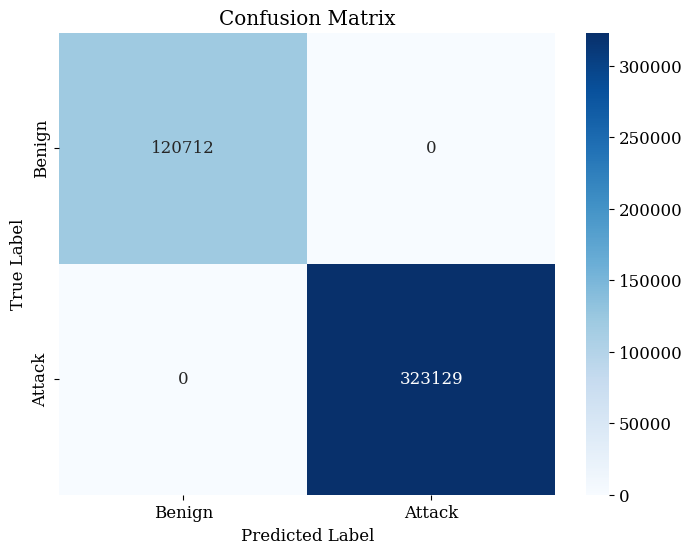

In [14]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
class_names = ["Benign", "Attack"]
# === 🧠 Step 1: Predictions ===
y_pred_probs = model.predict(X_test, verbose=1)  # Predict probabilities
y_pred_classes = (y_pred_probs > 0.5).astype(int).flatten()  # Threshold at 0.5

# === 📋 Step 2: Metrics Calculation ===
# Accuracy
accuracy = accuracy_score(y_test, y_pred_classes)

# Precision, Recall, F1
precision = precision_score(y_test, y_pred_classes)
recall = recall_score(y_test, y_pred_classes)
f1 = f1_score(y_test, y_pred_classes)

# AUC Score
auc = roc_auc_score(y_test, y_pred_probs)

# Print all metrics
print(f"\n✅ Evaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

# === 📋 Step 3: Full Classification Report (4 digits)
print("\n📄 Full Classification Report (4 Digits Precision):")
print(classification_report(
    y_test, y_pred_classes, target_names=class_names, digits=4
))

# === 📊 Step 4: Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## **Classification Report**

In [15]:
from sklearn.metrics import classification_report

# Assuming y_test (true labels) and y_pred_classes (predicted labels) are ready
print("\n📋 Classification Report (4 Digits Precision):")
print(classification_report(
    y_test,
    y_pred_classes,
    target_names=class_names,
    digits=4
))


📋 Classification Report (4 Digits Precision):
              precision    recall  f1-score   support

      Benign     1.0000    1.0000    1.0000    120712
      Attack     1.0000    1.0000    1.0000    323129

    accuracy                         1.0000    443841
   macro avg     1.0000    1.0000    1.0000    443841
weighted avg     1.0000    1.0000    1.0000    443841



## **Confusion Matrix**

13871/13871 ━━━━━━━━━━━━━━━━━━━━ 60s 4ms/step


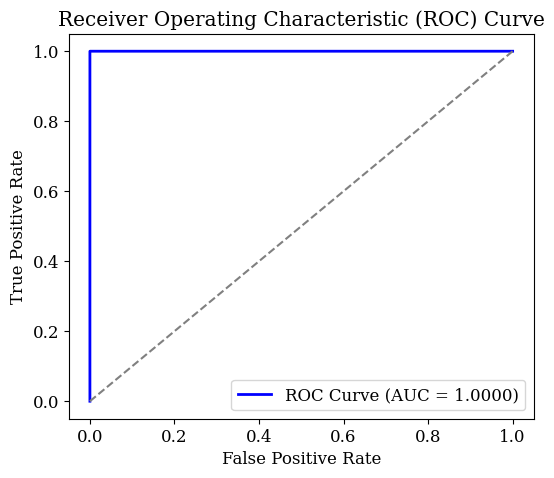

In [17]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ✅ Predict probabilities for the positive class
y_pred_probs = model.predict(X_test).ravel()

# ✅ Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

# ✅ Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Overall AUC Score (OvR): 1.0000


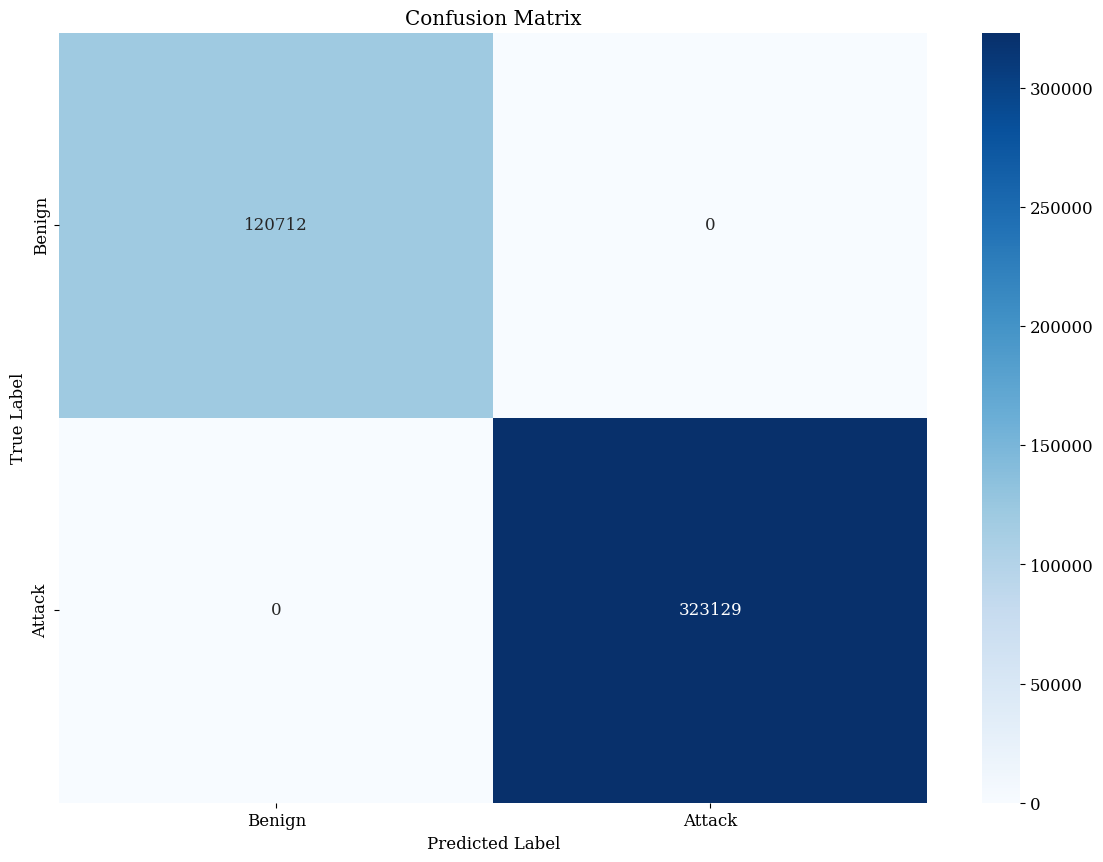

In [18]:
# === Step 3: AUC Score ===
# NOTE: For multi-class, use "ovr" (one-vs-rest) strategy
auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
print(f"Overall AUC Score (OvR): {auc_score:.4f}")

# === Step 5: Confusion Matrix ===
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


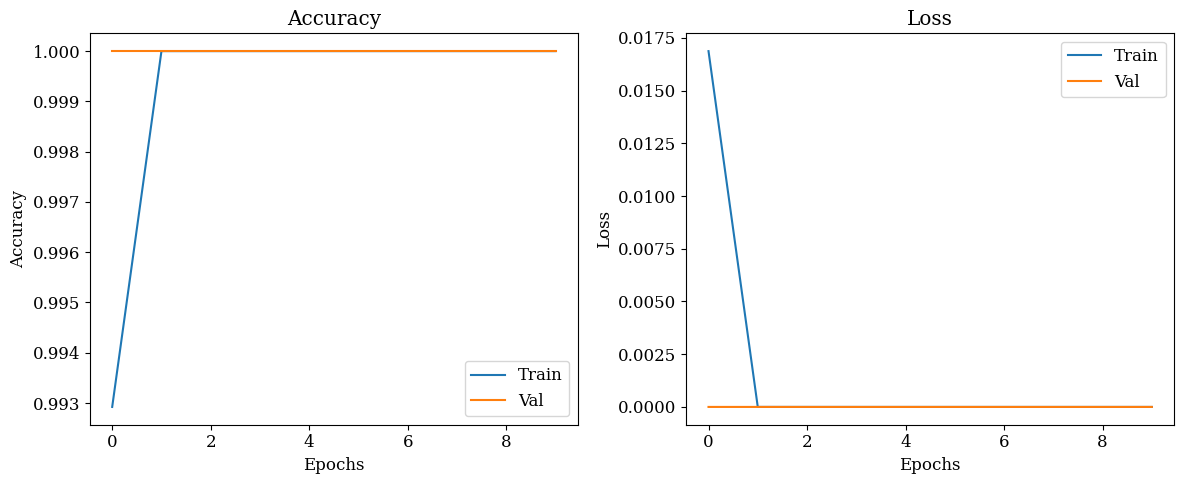

13871/13871 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step
13871/13871 ━━━━━━━━━━━━━━━━━━━━ 79s 6ms/step - accuracy: 1.0000 - loss: 3.0292e-12

✅ Test Accuracy: 1.0000

📊 Classification Report:

              precision    recall  f1-score   support

      Benign       0.27      1.00      0.43    120712
      Attack       0.00      0.00      0.00    323129

    accuracy                           0.27    443841
   macro avg       0.14      0.50      0.21    443841
weighted avg       0.07      0.27      0.12    443841



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


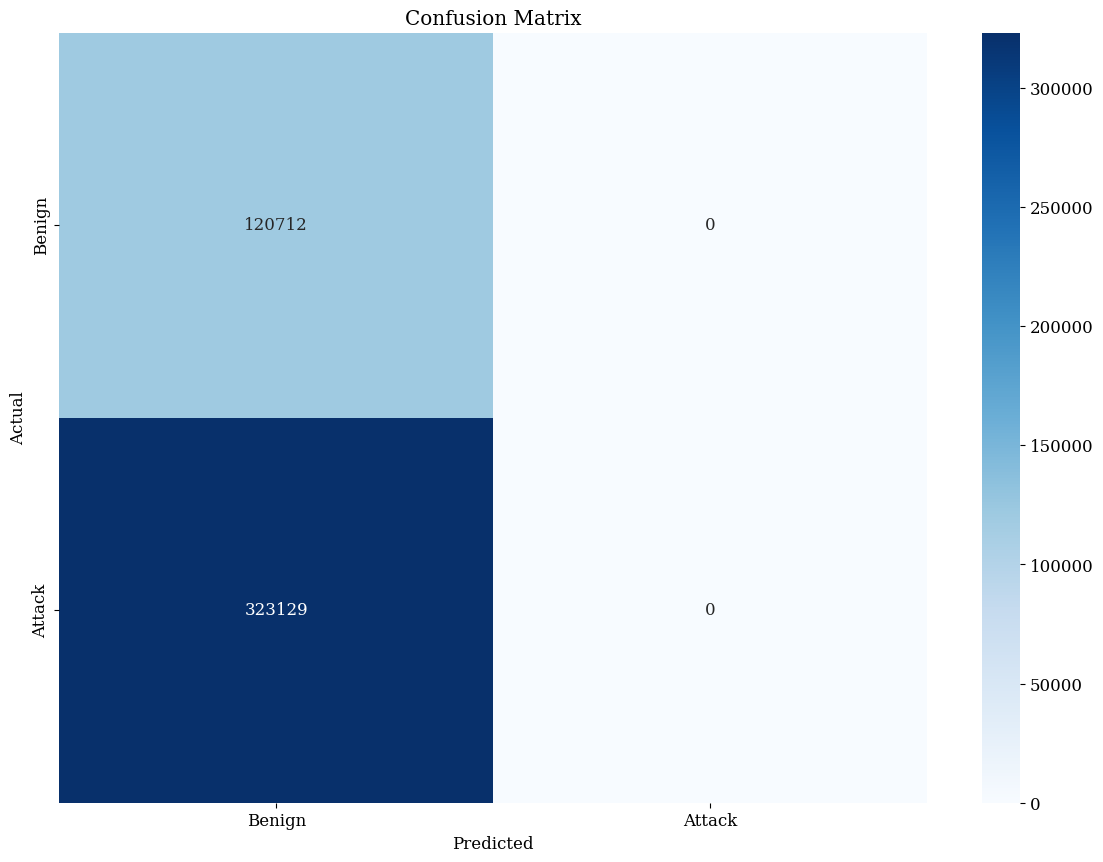

In [19]:
# === 📈 STEP 5: Plot Training History ===
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# === 🧪 STEP 6: Evaluation ===
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict and evaluate
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

# Classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
from tensorflow.keras.utils import plot_model

# ✅ Save a nice architecture diagram
plot_model(model,
           to_file='cst_afnet_architecture.png',
           show_shapes=True,
           show_layer_names=True,
           expand_nested=True,
           dpi=100)